# EcoSim Long-Horizon Evaluation Experiments

This notebook runs long, single-episode evaluations for selected saved agent models and records the simulation step by step so you can inspect whether the population dynamics still follow the expected equations over long time horizons.

It is meant for analysis only. It should keep the exact model paths, seed, episode length, environment settings, and fitted-theory parameters used for each run so the results can be reproduced later.

Recommended extra contents:
- exact prey and predator model file paths
- seed used for each run
- number of steps in the long episode
- environment settings such as agent counts and map choice
- a CSV/Parquet summary row per experiment
- fitted equation parameters for the theoretical comparison
- a short notes cell for anomalies or failed runs

In [10]:
from __future__ import annotations

from contextlib import contextmanager
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple
import copy
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'pyproject.toml').exists():
            return candidate
    return start


ROOT = find_repo_root(Path.cwd().resolve())
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config.config import SEED, STEPS_PER_EPISODE
from agents.agent import Prey, Predator
from environment.gym_env import EcoSimEnv
from models.Q_learning import QLearningAgent

In [25]:
# --- Conservative experiment configuration: compare all run-39 cycle pairs ---
# This notebook evaluates every saved cycle pair from run 39 at 2000 steps.
# It runs both prey-main and predator-main perspectives across three seeds.
cycle_ids = [1, 2, 3, 4, 5]
seed_offsets = [0, 1, 2]
evaluation_runs = []
for cycle_id in cycle_ids:
    prey_model = ROOT / 'src' / 'models' / f'trained_prey_39_protocol2_cycle{cycle_id}.pkl'
    predator_model = ROOT / 'src' / 'models' / f'trained_predator_39_protocol2_cycle{cycle_id}.pkl'
    for seed_offset in seed_offsets:
        evaluation_runs.append({
            'run_name': f'cycle{cycle_id}_prey_seed{seed_offset}',
            'prey_model_name': str(prey_model),
            'predator_model_name': str(predator_model),
            'agent_type': 'PREY',
            'seed_offset': seed_offset,
        })
        evaluation_runs.append({
            'run_name': f'cycle{cycle_id}_predator_seed{seed_offset}',
            'prey_model_name': str(prey_model),
            'predator_model_name': str(predator_model),
            'agent_type': 'PREDATOR',
            'seed_offset': seed_offset,
        })

# Long single-episode rollout length per experiment.
long_episode_steps = 2_000

# Override the global step cap used by the environment and evaluation helpers.
import config.config as config_module
import environment.gym_env as gym_env_module
import environment.multi_agent_gym_env as multi_env_module
import models.Q_learning as q_learning_module
config_module.STEPS_PER_EPISODE = long_episode_steps
gym_env_module.STEPS_PER_EPISODE = long_episode_steps
multi_env_module.STEPS_PER_EPISODE = long_episode_steps
q_learning_module.STEPS_PER_EPISODE = long_episode_steps
STEPS_PER_EPISODE = long_episode_steps

# Keep evaluation deterministic.
eval_seed = SEED
frozen_policy_epsilon = 0.0

# Environment setup for long-term dynamics testing.
num_prey = 30
num_predators = 10
map_path = None
memory = False

results_dir = ROOT / 'src' / 'models' / 'results' / 'long_horizon_evaluation' / 'run39_all_cycles_2000'
results_dir.mkdir(parents=True, exist_ok=True)

print(f'Repo root: {ROOT}')
print(f'Results directory: {results_dir}')
print(f'Long episode length: {long_episode_steps} steps')
print(f'Global step cap overridden to: {STEPS_PER_EPISODE}')
print(f'Cycles configured: {cycle_ids}')
print(f'Seeds configured: {seed_offsets}')
print(f'Runs configured: {len(evaluation_runs)}')

Repo root: C:\Users\alejl\University\Thesis\ecoSim
Results directory: C:\Users\alejl\University\Thesis\ecoSim\src\models\results\long_horizon_evaluation\run39_all_cycles_2000
Long episode length: 2000 steps
Global step cap overridden to: 2000
Cycles configured: [1, 2, 3, 4, 5]
Seeds configured: [0, 1, 2]
Runs configured: 30


## Load Saved Agent Models and Initialize Helpers

This cell resolves saved model names, clones frozen evaluation policies, and prepares a lightweight event tracker for births and predation counts.

In [12]:
def resolve_model_path(model_name: str, species: str) -> Path:
    model_name = str(model_name).strip()
    models_dir = ROOT / 'src' / 'models'

    if model_name.lower() == 'latest':
        candidates = sorted(models_dir.glob(f'trained_{species.lower()}_*.pkl'), key=lambda p: p.stat().st_mtime)
        if candidates:
            return candidates[-1]
        raise FileNotFoundError(f'No {species.lower()} models found in {models_dir}')

    direct_path = Path(model_name)
    if direct_path.exists():
        return direct_path

    if not model_name.endswith('.pkl'):
        model_name = f'{model_name}.pkl'

    exact_path = models_dir / model_name
    if exact_path.exists():
        return exact_path

    candidates = sorted(models_dir.glob(f'trained_{species.lower()}_*.pkl'), key=lambda p: p.stat().st_mtime)
    exact_stem = [path for path in candidates if path.stem == Path(model_name).stem]
    if exact_stem:
        return exact_stem[-1]

    partial = [path for path in candidates if Path(model_name).stem.lower() in path.stem.lower()]
    if partial:
        return partial[-1]

    raise FileNotFoundError(f'Could not resolve {species.lower()} model from {model_name!r}')


@dataclass
class EventTracker:
    prey_births: int = 0
    predator_births: int = 0
    predation_events: int = 0


@contextmanager
def track_ecosim_events(tracker: EventTracker):
    original_prey_reproduce = Prey.reproduce
    original_predator_reproduce = Predator.reproduce
    original_predator_eat = Predator.eat

    def wrapped_prey_reproduce(self, *args, **kwargs):
        offspring = original_prey_reproduce(self, *args, **kwargs)
        if offspring is not None:
            tracker.prey_births += 1
        return offspring

    def wrapped_predator_reproduce(self, *args, **kwargs):
        offspring = original_predator_reproduce(self, *args, **kwargs)
        if offspring is not None:
            tracker.predator_births += 1
        return offspring

    def wrapped_predator_eat(self, *args, **kwargs):
        reward = original_predator_eat(self, *args, **kwargs)
        if reward > 0:
            tracker.predation_events += 1
        return reward

    Prey.reproduce = wrapped_prey_reproduce
    Predator.reproduce = wrapped_predator_reproduce
    Predator.eat = wrapped_predator_eat
    try:
        yield
    finally:
        Prey.reproduce = original_prey_reproduce
        Predator.reproduce = original_predator_reproduce
        Predator.eat = original_predator_eat


def clone_frozen_agent(model_path: Path, agent_id: int = 0) -> QLearningAgent:
    agent = QLearningAgent.load_model_from_file(str(model_path))
    agent.agent_id = agent_id
    agent.epsilon = 0.0
    return agent


def mean_or_zero(values):
    values = list(values)
    return float(np.mean(values)) if values else 0.0

## Run Long-Episode Evaluation and Log Data by Step

Each experiment below runs one uninterrupted episode per model pair, records state every step, and writes the full trajectory to disk.

In [13]:
def build_step_snapshot(env, step_index: int, reward: float, cumulative_reward: float, tracker: EventTracker, previous_alive_ids: set[int], known_agent_types: Dict[int, str]) -> Tuple[Dict, set[int]]:
    all_agents = [env.agent] + list(env.other_agents)
    alive_agents = [agent for agent in all_agents if agent.is_alive()]
    prey_agents = [agent for agent in alive_agents if agent.agent_type == 'PREY']
    predator_agents = [agent for agent in alive_agents if agent.agent_type == 'PREDATOR']

    current_alive_ids = {agent.agent_id for agent in alive_agents}
    for agent in all_agents:
        known_agent_types.setdefault(agent.agent_id, agent.agent_type)

    deaths = previous_alive_ids - current_alive_ids
    prey_deaths = sum(1 for agent_id in deaths if known_agent_types.get(agent_id) == 'PREY')
    predator_deaths = sum(1 for agent_id in deaths if known_agent_types.get(agent_id) == 'PREDATOR')

    main_agent = env.agent
    main_observation = main_agent.get_observation(env.env)

    snapshot = {
        'step': step_index,
        'reward': reward,
        'cumulative_reward': cumulative_reward,
        'main_agent_type': main_agent.agent_type,
        'main_agent_energy': float(main_agent.energy),
        'main_agent_sensor_flag': int(main_observation[6]),
        'main_agent_target_detected': int(main_observation[4]),
        'prey_population': len(prey_agents),
        'predator_population': len(predator_agents),
        'total_alive': len(alive_agents),
        'avg_prey_energy': mean_or_zero(agent.energy for agent in prey_agents),
        'avg_predator_energy': mean_or_zero(agent.energy for agent in predator_agents),
        'min_prey_energy': float(min((agent.energy for agent in prey_agents), default=0.0)),
        'max_prey_energy': float(max((agent.energy for agent in prey_agents), default=0.0)),
        'min_predator_energy': float(min((agent.energy for agent in predator_agents), default=0.0)),
        'max_predator_energy': float(max((agent.energy for agent in predator_agents), default=0.0)),
        'cumulative_prey_births': tracker.prey_births,
        'cumulative_predator_births': tracker.predator_births,
        'cumulative_predation_events': tracker.predation_events,
        'cumulative_prey_deaths': build_step_snapshot.cumulative_prey_deaths + prey_deaths,
        'cumulative_predator_deaths': build_step_snapshot.cumulative_predator_deaths + predator_deaths,
    }
    return snapshot, current_alive_ids


build_step_snapshot.cumulative_prey_deaths = 0
build_step_snapshot.cumulative_predator_deaths = 0


def run_long_episode_experiment(run_spec: Dict, run_index: int) -> Tuple[pd.DataFrame, Dict]:
    prey_model_path = resolve_model_path(run_spec['prey_model_name'], 'PREY')
    predator_model_path = resolve_model_path(run_spec['predator_model_name'], 'PREDATOR')
    main_agent_type = str(run_spec.get('agent_type', 'PREY')).upper()
    run_name = run_spec.get('run_name', f'run_{run_index + 1}')
    seed_offset = int(run_spec.get('seed_offset', run_index))

    prey_policy = clone_frozen_agent(prey_model_path, agent_id=0)
    predator_policy = clone_frozen_agent(predator_model_path, agent_id=1)
    prey_policy.epsilon = 0.0
    predator_policy.epsilon = 0.0

    if main_agent_type == 'PREY':
        main_policy = prey_policy
        opponent_policy = predator_policy
        same_species_policy = clone_frozen_agent(prey_model_path, agent_id=2)
        opponent_label = 'PREDATOR'
        same_species_label = 'PREY'
    else:
        main_policy = predator_policy
        opponent_policy = prey_policy
        same_species_policy = clone_frozen_agent(predator_model_path, agent_id=2)
        opponent_label = 'PREY'
        same_species_label = 'PREDATOR'

    same_species_policy.epsilon = 0.0

    tracker = EventTracker()
    records: List[Dict] = []

    with track_ecosim_events(tracker):
        env = EcoSimEnv(
            agent_id=0,
            num_prey=num_prey,
            num_predators=num_predators,
            agent_type=main_agent_type,
            map_path=map_path,
            memory=memory,
            opponent_agent=opponent_policy,
            opponent_type=opponent_label,
            same_species_agent=same_species_policy,
            same_species_type=same_species_label,
            frozen_policy_epsilon=frozen_policy_epsilon,
        )

        observation = env.reset(seed=eval_seed + seed_offset)
        previous_alive_ids = {agent.agent_id for agent in [env.agent] + list(env.other_agents) if agent.is_alive()}
        known_agent_types = {agent.agent_id: agent.agent_type for agent in [env.agent] + list(env.other_agents)}
        cumulative_reward = 0.0

        for step_index in range(1, long_episode_steps + 1):
            main_state = main_policy.discretize_state(observation)
            action = main_policy.select_action(main_state, training=False)
            observation, reward, done, info = env.step(action)
            cumulative_reward += reward

            snapshot, previous_alive_ids = build_step_snapshot(
                env,
                step_index,
                reward,
                cumulative_reward,
                tracker,
                previous_alive_ids,
                known_agent_types,
            )
            records.append(snapshot)

            if done:
                break

    results_df = pd.DataFrame(records)
    results_df['prey_model_path'] = str(prey_model_path)
    results_df['predator_model_path'] = str(predator_model_path)
    results_df['run_name'] = run_name
    results_df['seed'] = eval_seed + seed_offset
    results_df['long_episode_steps'] = long_episode_steps

    csv_path = results_dir / f"{run_name}__{prey_model_path.stem}__{predator_model_path.stem}_{len(results_df)}steps.csv"
    results_df.to_csv(csv_path, index=False)

    summary = {
        'run_name': run_name,
        'prey_model_path': str(prey_model_path),
        'predator_model_path': str(predator_model_path),
        'seed': eval_seed + seed_offset,
        'steps_ran': int(len(results_df)),
        'final_reward': float(results_df['cumulative_reward'].iloc[-1]) if not results_df.empty else 0.0,
        'final_prey_population': int(results_df['prey_population'].iloc[-1]) if not results_df.empty else 0,
        'final_predator_population': int(results_df['predator_population'].iloc[-1]) if not results_df.empty else 0,
        'cumulative_predation_events': int(results_df['cumulative_predation_events'].iloc[-1]) if not results_df.empty else 0,
        'cumulative_prey_births': int(results_df['cumulative_prey_births'].iloc[-1]) if not results_df.empty else 0,
        'cumulative_predator_births': int(results_df['cumulative_predator_births'].iloc[-1]) if not results_df.empty else 0,
        'csv_path': str(csv_path),
    }
    return results_df, summary

In [26]:
all_run_summaries = []
all_run_frames = []

for run_index, run_spec in enumerate(evaluation_runs):
    results_df, summary = run_long_episode_experiment(run_spec, run_index)
    all_run_frames.append(results_df)
    all_run_summaries.append(summary)
    print(f"Saved {summary['csv_path']} | steps={summary['steps_ran']} | final prey={summary['final_prey_population']} | final predator={summary['final_predator_population']}")

summary_df = pd.DataFrame(all_run_summaries)
summary_df

✓ Using custom opponent agent for PREDATOR
✓ Using frozen same-species policy for PREY (eps=0.000)
Saved C:\Users\alejl\University\Thesis\ecoSim\src\models\results\long_horizon_evaluation\run39_all_cycles_2000\cycle1_prey_seed0__trained_prey_39_protocol2_cycle1__trained_predator_39_protocol2_cycle1_567steps.csv | steps=567 | final prey=233 | final predator=146
✓ Using custom opponent agent for PREY
✓ Using frozen same-species policy for PREDATOR (eps=0.000)
Saved C:\Users\alejl\University\Thesis\ecoSim\src\models\results\long_horizon_evaluation\run39_all_cycles_2000\cycle1_predator_seed0__trained_prey_39_protocol2_cycle1__trained_predator_39_protocol2_cycle1_749steps.csv | steps=749 | final prey=288 | final predator=148
✓ Using custom opponent agent for PREDATOR
✓ Using frozen same-species policy for PREY (eps=0.000)
Saved C:\Users\alejl\University\Thesis\ecoSim\src\models\results\long_horizon_evaluation\run39_all_cycles_2000\cycle1_prey_seed1__trained_prey_39_protocol2_cycle1__trained

,run_name,prey_model_path,predator_model_path,seed,steps_ran,final_reward,final_prey_population,final_predator_population,cumulative_predation_events,cumulative_prey_births,cumulative_predator_births,csv_path
0,cycle1_prey_seed0,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,42,567,17695.400000,233,146,772,978,144,C:\Users\alejl\University\Thesis\ecoSim\src\mo...
1,cycle1_predator_seed0,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,42,749,117.400000,288,148,1226,1485,165,C:\Users\alejl\University\Thesis\ecoSim\src\mo...
2,cycle1_prey_seed1,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,43,595,222.990000,337,39,176,482,34,C:\Users\alejl\University\Thesis\ecoSim\src\mo...
3,cycle1_predator_seed1,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,43,535,199.000000,337,169,901,1208,186,C:\Users\alejl\University\Thesis\ecoSim\src\mo...
4,cycle1_prey_seed2,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,44,14,187.810000,25,10,6,0,0,C:\Users\alejl\University\Thesis\ecoSim\src\mo...
5,cycle1_predator_seed2,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,44,154,-11.540000,337,18,47,354,9,C:\Users\alejl\University\Thesis\ecoSim\src\mo...
6,cycle2_prey_seed0,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,42,62,28.370000,22,10,9,0,0,C:\Users\alejl\University\Thesis\ecoSim\src\mo...
7,cycle2_predator_seed0,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,42,631,32.276667,337,169,1126,1433,222,C:\Users\alejl\University\Thesis\ecoSim\src\mo...
8,cycle2_prey_seed1,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,43,120,67.280000,337,11,16,322,1,C:\Users\alejl\University\Thesis\ecoSim\src\mo...
9,cycle2_predator_seed1,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,43,399,-13.990000,337,169,826,1133,160,C:\Users\alejl\University\Thesis\ecoSim\src\mo...


## Analyze Population Dynamics

This section fits a simple discrete Lotka-Volterra-style model to the observed step data and compares the fitted trajectory against the measured populations.

In [21]:
def fit_lotka_volterra(observed_df: pd.DataFrame) -> Dict:
    series = observed_df[['prey_population', 'predator_population']].dropna().reset_index(drop=True)
    if len(series) < 3:
        return {'success': False, 'reason': 'not enough data'}

    x = series['prey_population'].to_numpy(dtype=float)
    y = series['predator_population'].to_numpy(dtype=float)

    dx = np.diff(x)
    dy = np.diff(y)
    x0 = x[:-1]
    y0 = y[:-1]

    prey_design = np.column_stack([x0, -x0 * y0])
    pred_design = np.column_stack([-y0, x0 * y0])

    prey_params, *_ = np.linalg.lstsq(prey_design, dx, rcond=None)
    pred_params, *_ = np.linalg.lstsq(pred_design, dy, rcond=None)

    alpha, beta = prey_params
    gamma, delta = pred_params

    x_hat = [x[0]]
    y_hat = [y[0]]
    for _ in range(1, len(x)):
        current_x = x_hat[-1]
        current_y = y_hat[-1]
        next_x = max(0.0, current_x + (alpha * current_x - beta * current_x * current_y))
        next_y = max(0.0, current_y + (-gamma * current_y + delta * current_x * current_y))
        x_hat.append(next_x)
        y_hat.append(next_y)

    x_hat = np.asarray(x_hat)
    y_hat = np.asarray(y_hat)

    rmse_prey = float(np.sqrt(np.mean((x - x_hat) ** 2)))
    rmse_predator = float(np.sqrt(np.mean((y - y_hat) ** 2)))

    return {
        'success': True,
        'alpha': float(alpha),
        'beta': float(beta),
        'gamma': float(gamma),
        'delta': float(delta),
        'prey_rmse': rmse_prey,
        'predator_rmse': rmse_predator,
        'prey_fitted': x_hat,
        'predator_fitted': y_hat,
    }


analysis_rows = []
for idx, run_df in enumerate(all_run_frames):
    fit = fit_lotka_volterra(run_df)
    if not fit.get('success'):
        analysis_rows.append({'run_index': idx, **fit})
        continue

    analysis_rows.append({
        'run_index': idx,
        'run_name': run_df['run_name'].iloc[0] if not run_df.empty else f'run_{idx + 1}',
        'prey_model_path': run_df['prey_model_path'].iloc[0] if not run_df.empty else '',
        'predator_model_path': run_df['predator_model_path'].iloc[0] if not run_df.empty else '',
        'alpha': fit['alpha'],
        'beta': fit['beta'],
        'gamma': fit['gamma'],
        'delta': fit['delta'],
        'prey_rmse': fit['prey_rmse'],
        'predator_rmse': fit['predator_rmse'],
    })

analysis_df = pd.DataFrame(analysis_rows)
analysis_df

,run_index,run_name,prey_model_path,predator_model_path,alpha,beta,gamma,delta,prey_rmse,predator_rmse
0,0,cycle5_prey_seed0,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,-0.042823,-0.003762,0.006414,0.000243,15.177951,4.496340
1,1,cycle5_predator_seed0,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,-0.007638,-0.000494,0.001996,0.000084,2.144571,1.241902
2,2,cycle5_prey_seed1,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,0.022099,0.002210,0.002603,0.000114,1.315514,0.365736
3,3,cycle5_predator_seed1,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,0.000927,0.000252,0.002616,0.000120,1.568669,1.311671
4,4,cycle5_prey_seed2,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,-0.000012,0.000121,0.000000,0.000000,3.035819,0.000000
5,5,cycle5_predator_seed2,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,C:\Users\alejl\University\Thesis\ecoSim\src\mo...,-0.022153,-0.001684,0.002907,0.000124,5.339769,1.770098


## Visualize Results Against Theoretical Equations

Observed step-level population trajectories are plotted against the fitted theoretical curves, alongside energy and reward diagnostics.

Saved fit summary to C:\Users\alejl\University\Thesis\ecoSim\src\models\results\long_horizon_evaluation\run39_all_cycles_2000\long_horizon_fit_summary.csv


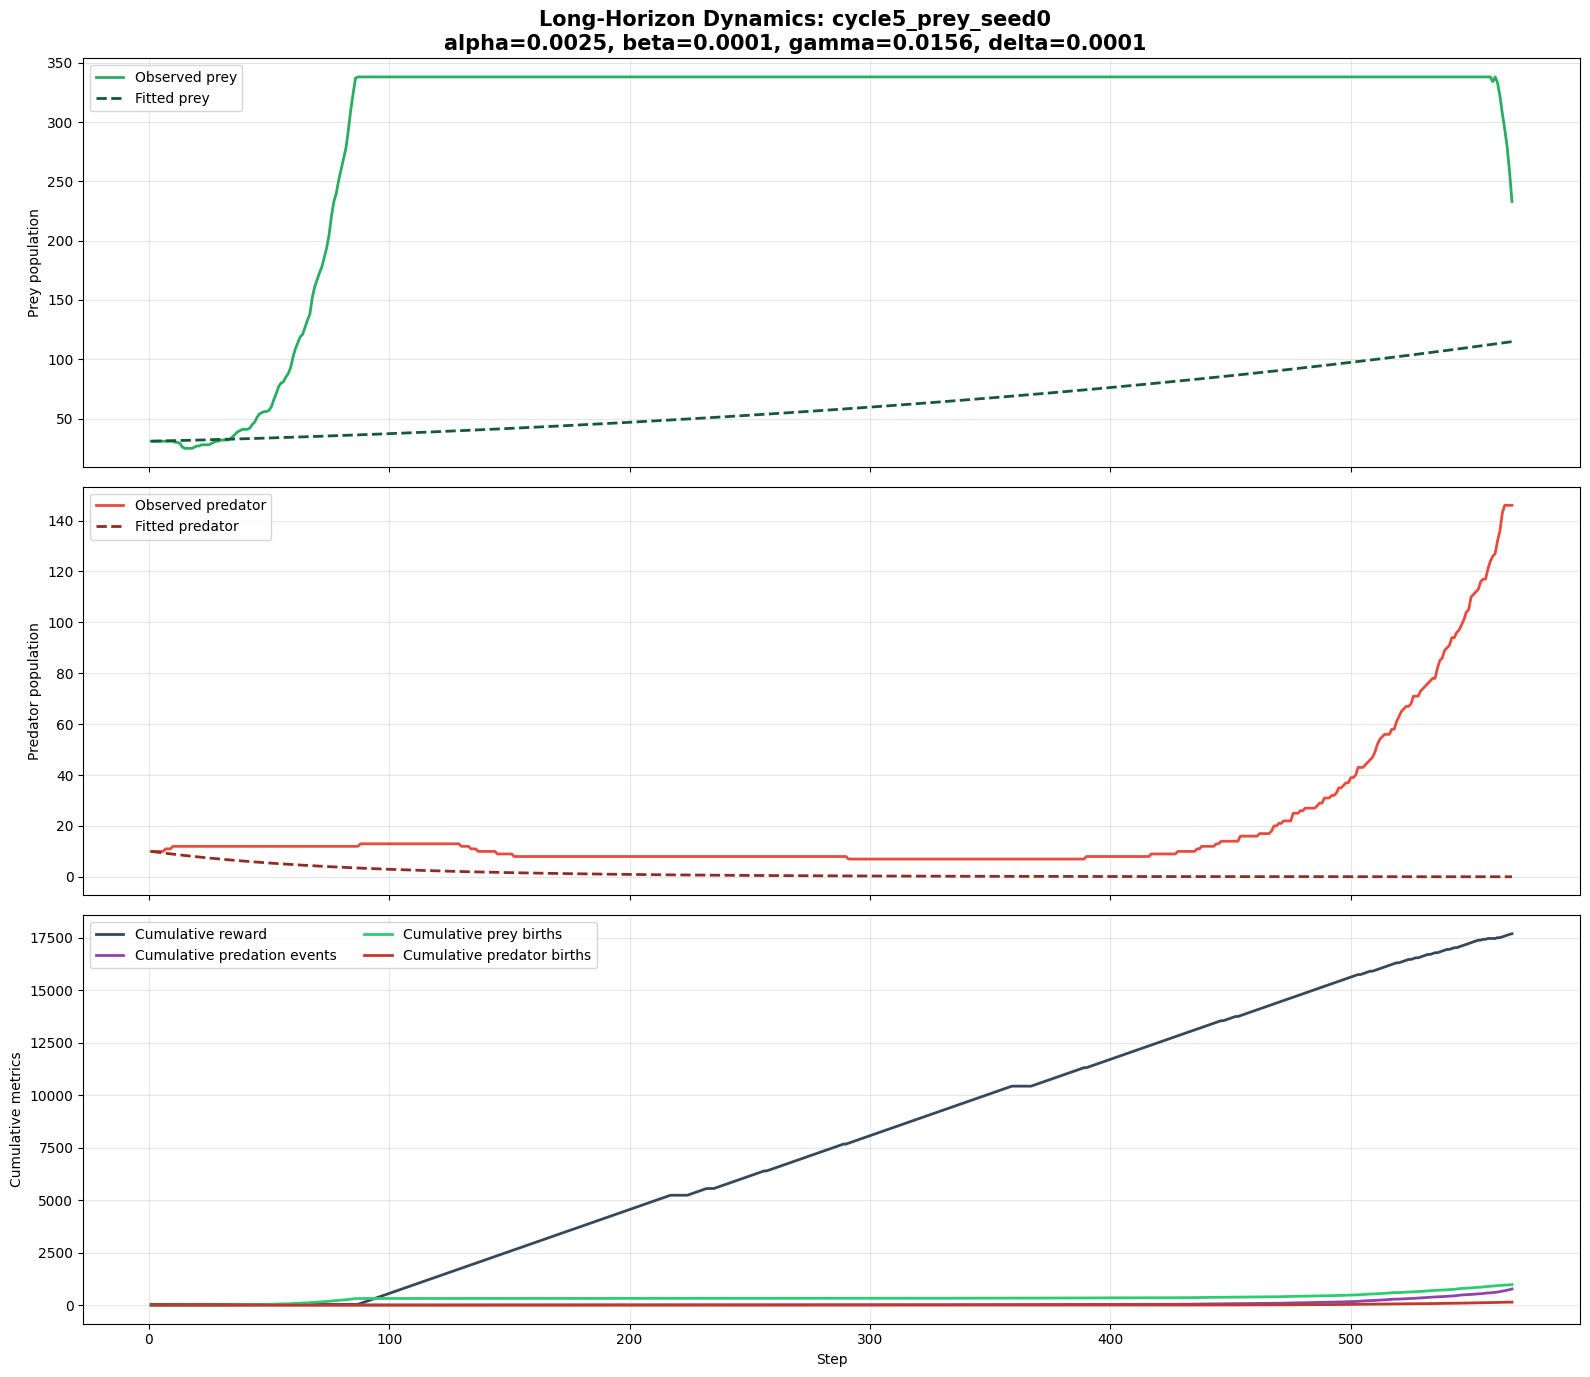

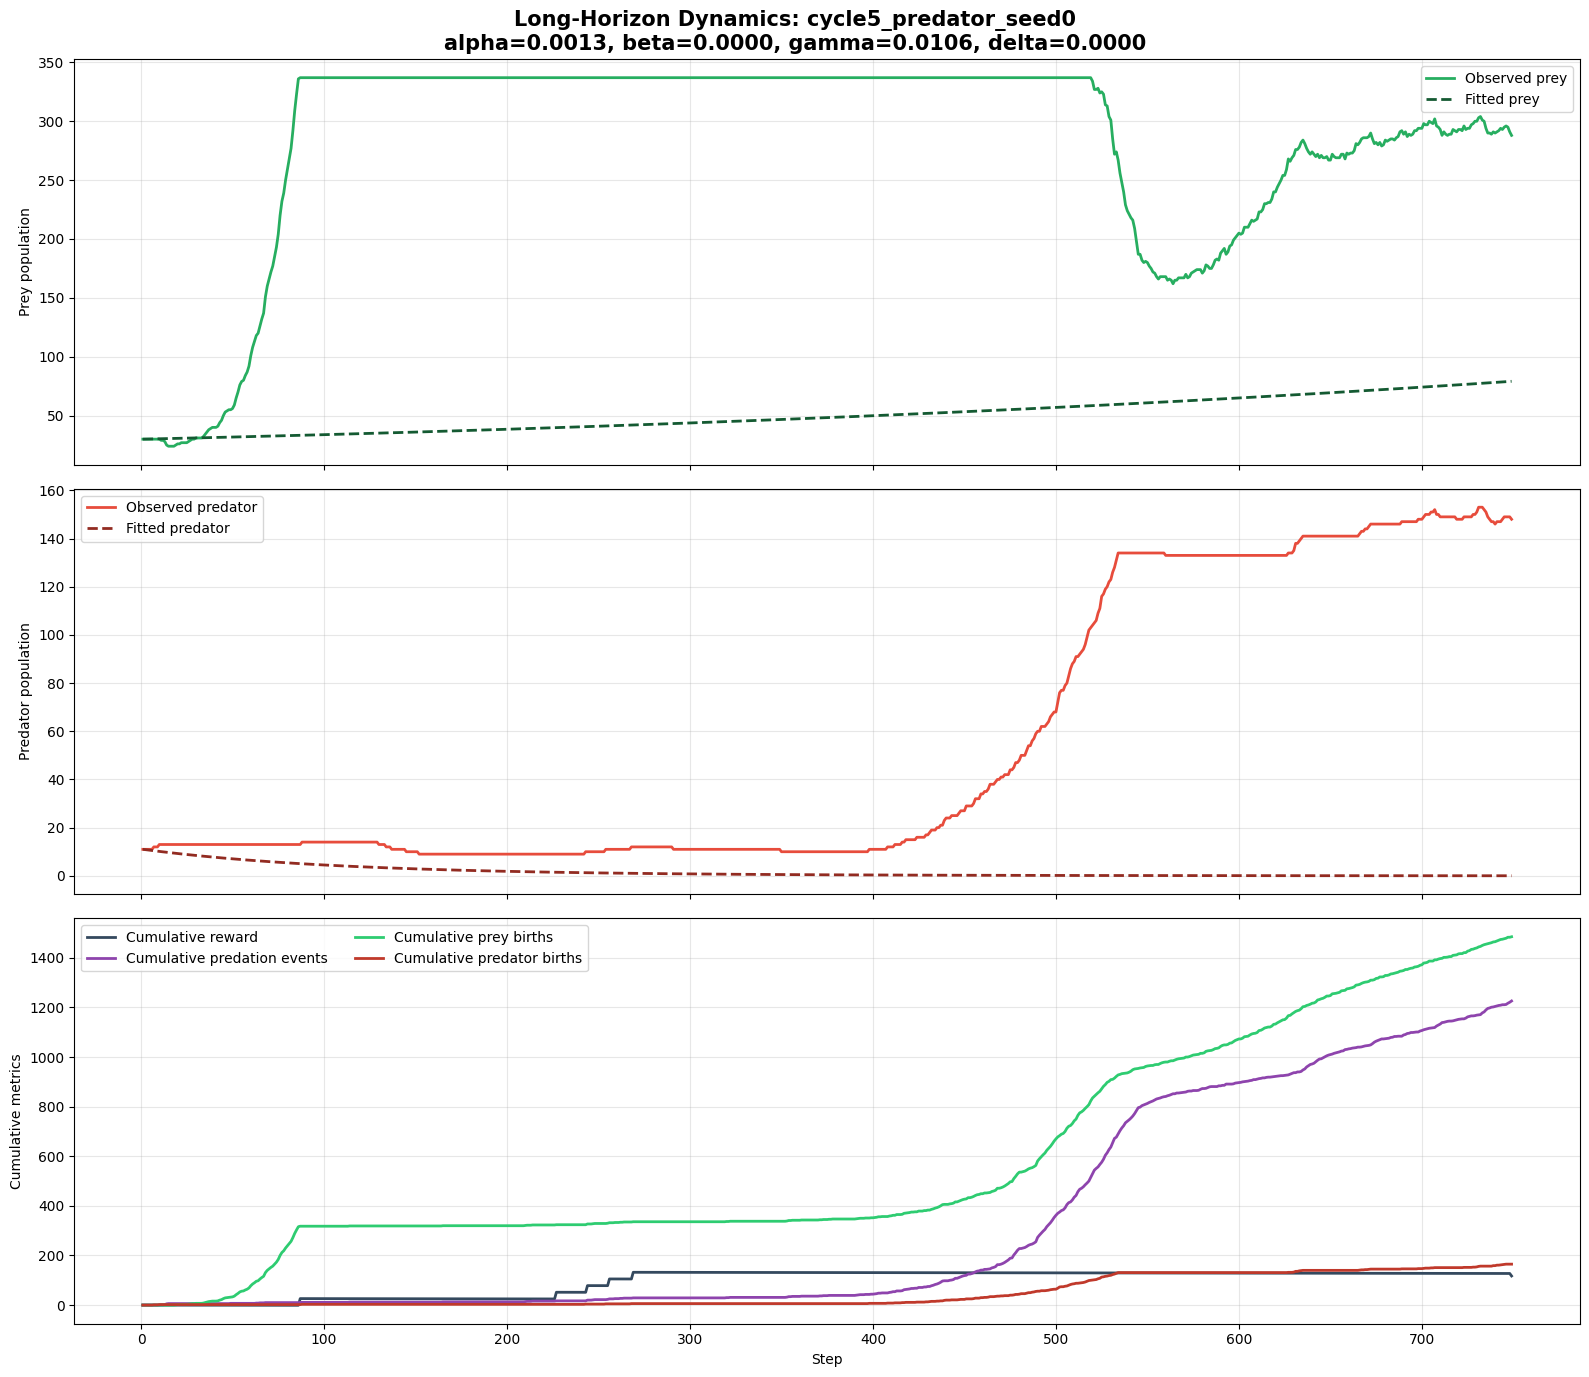

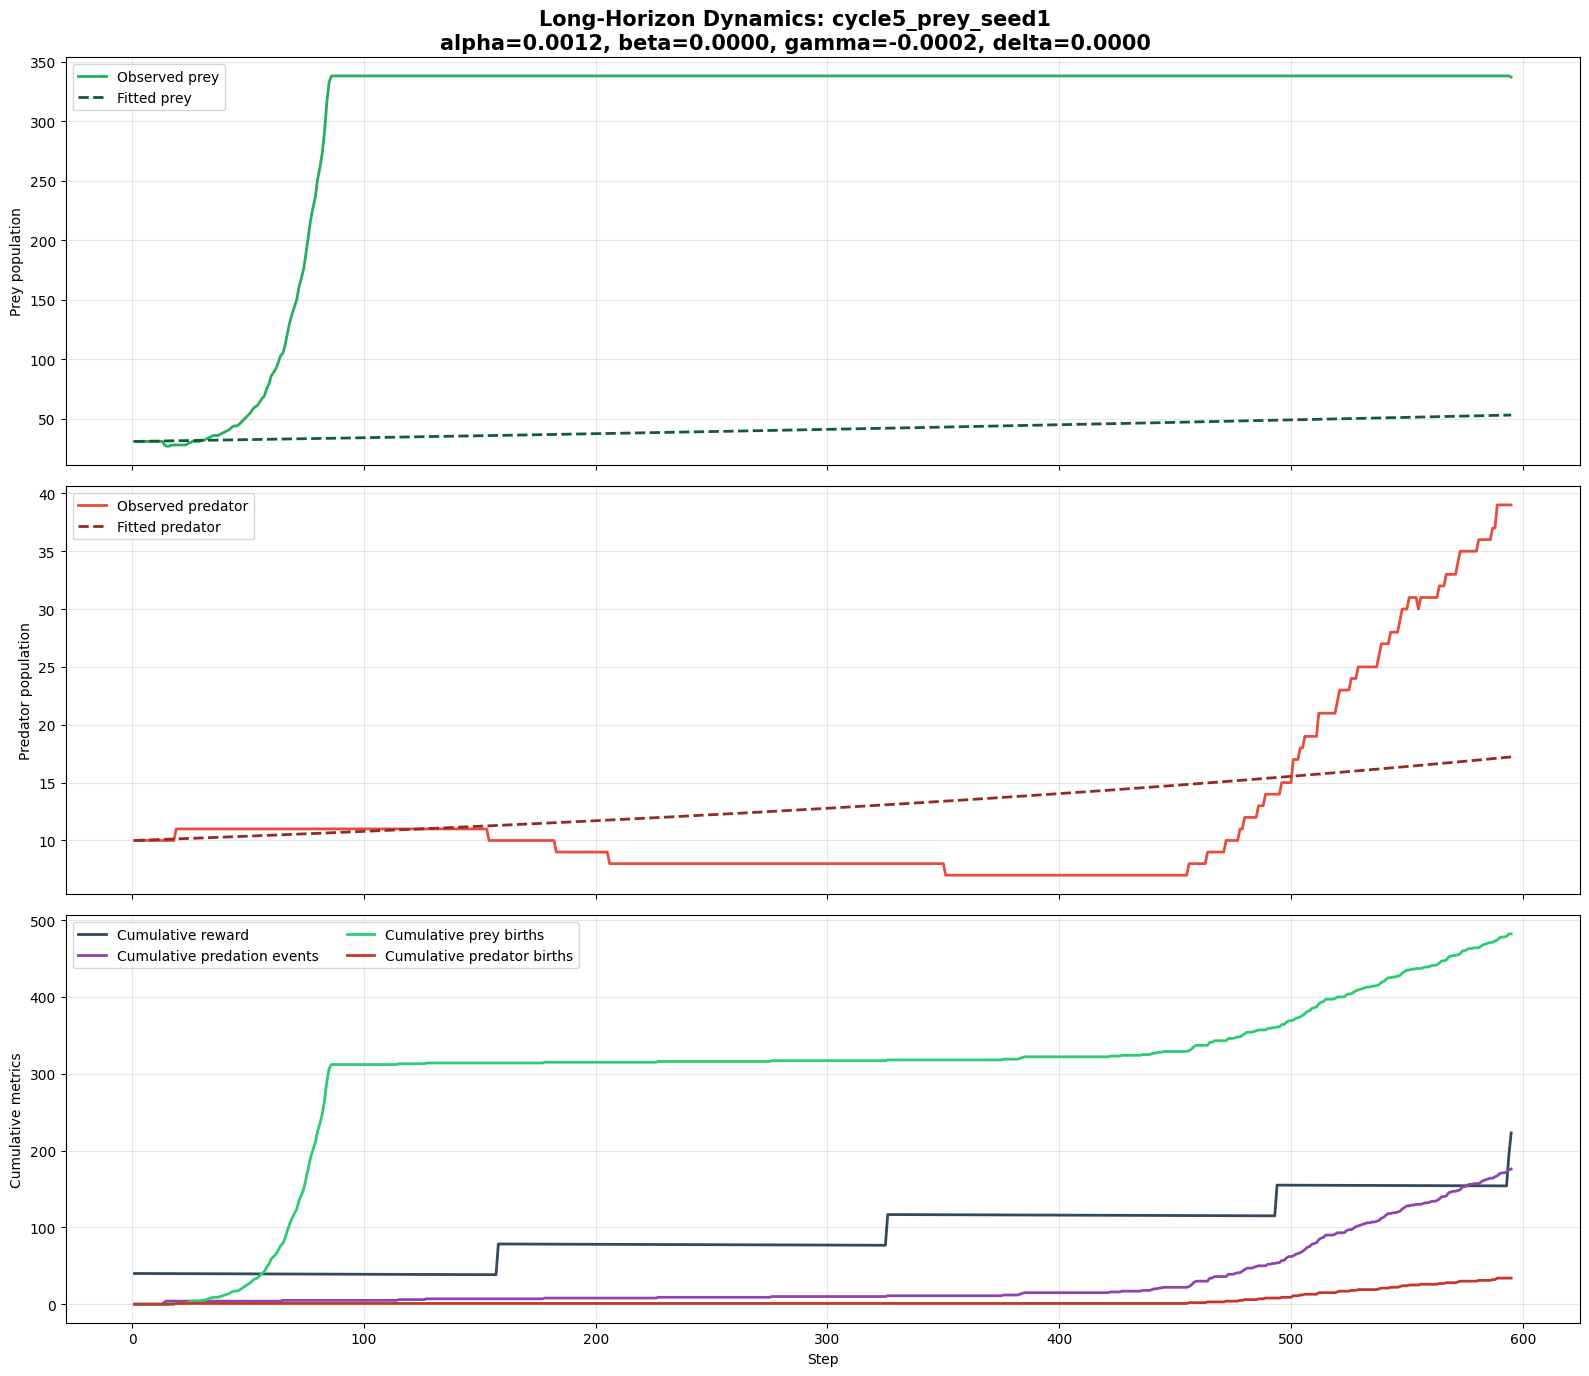

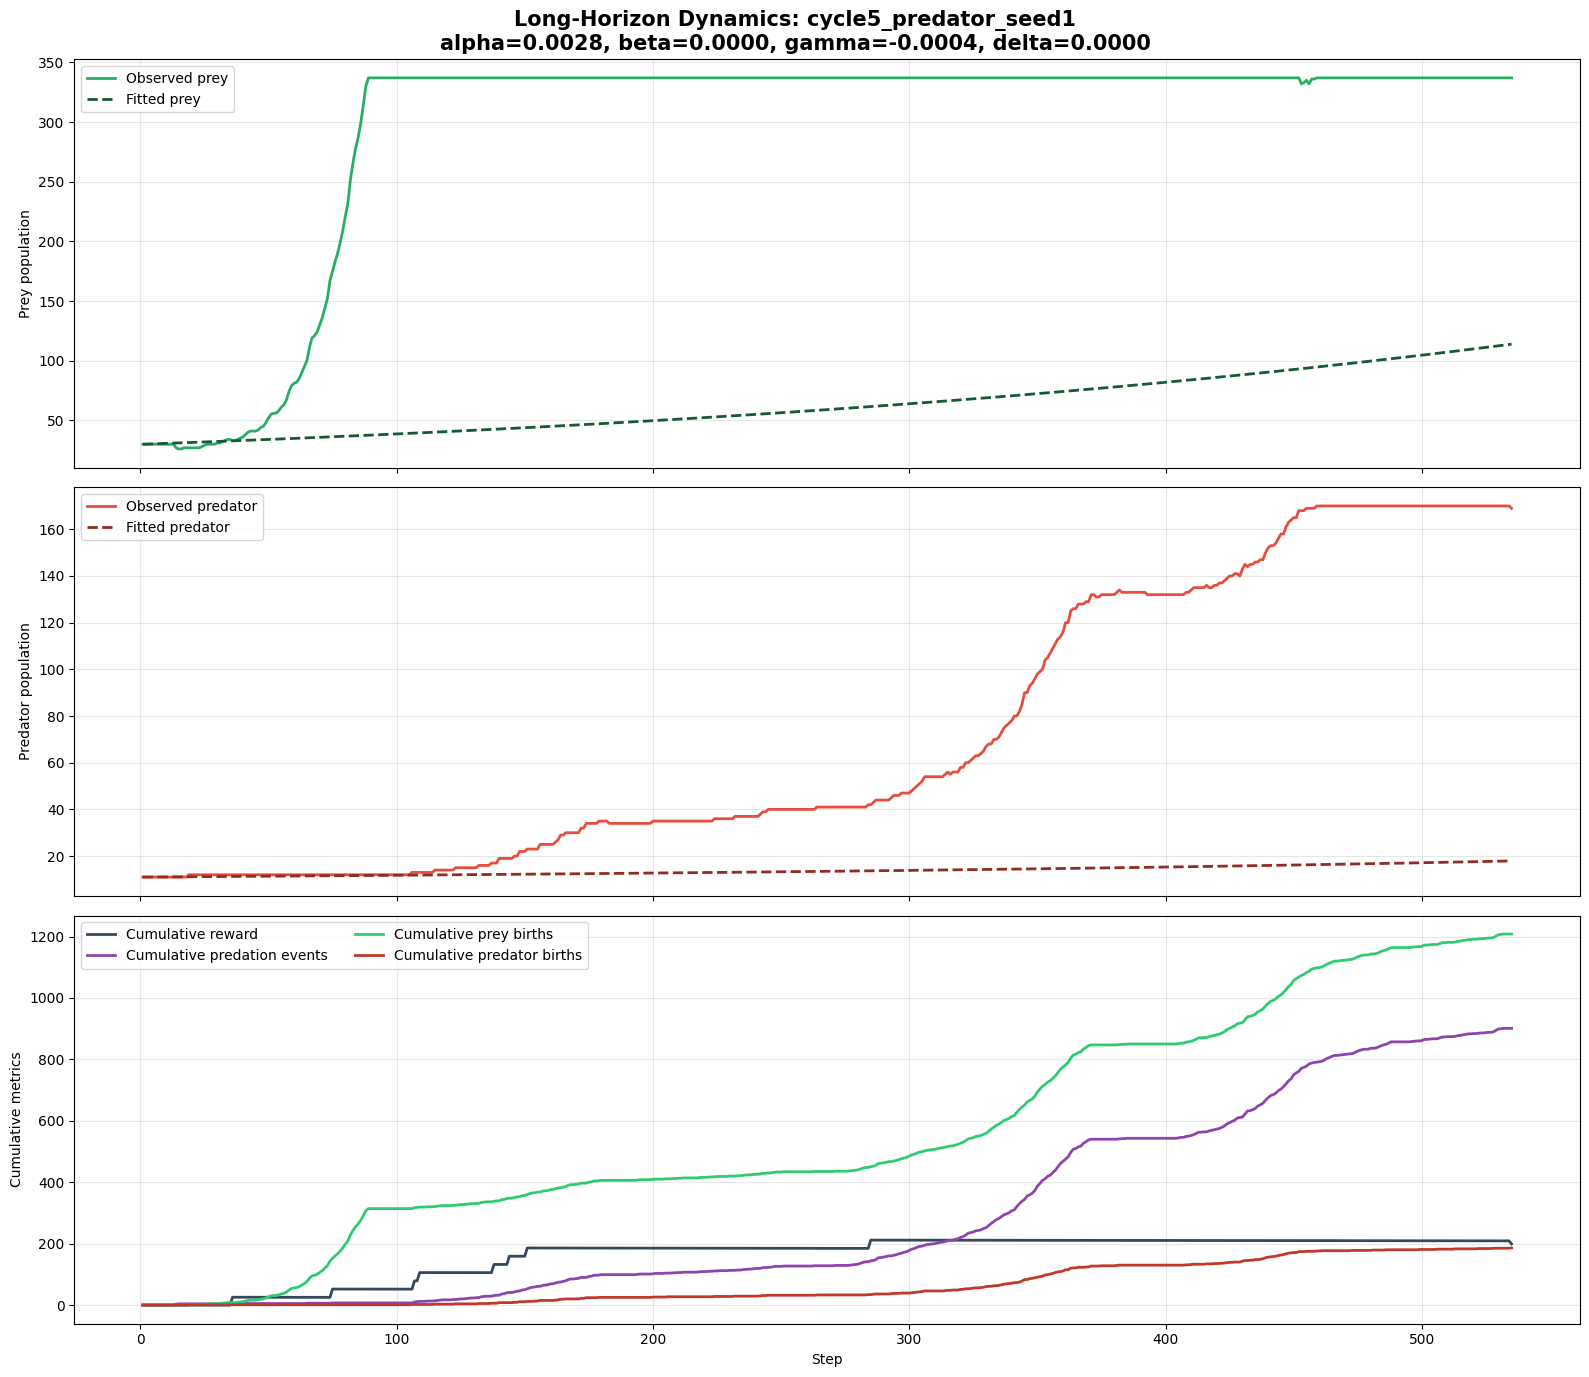

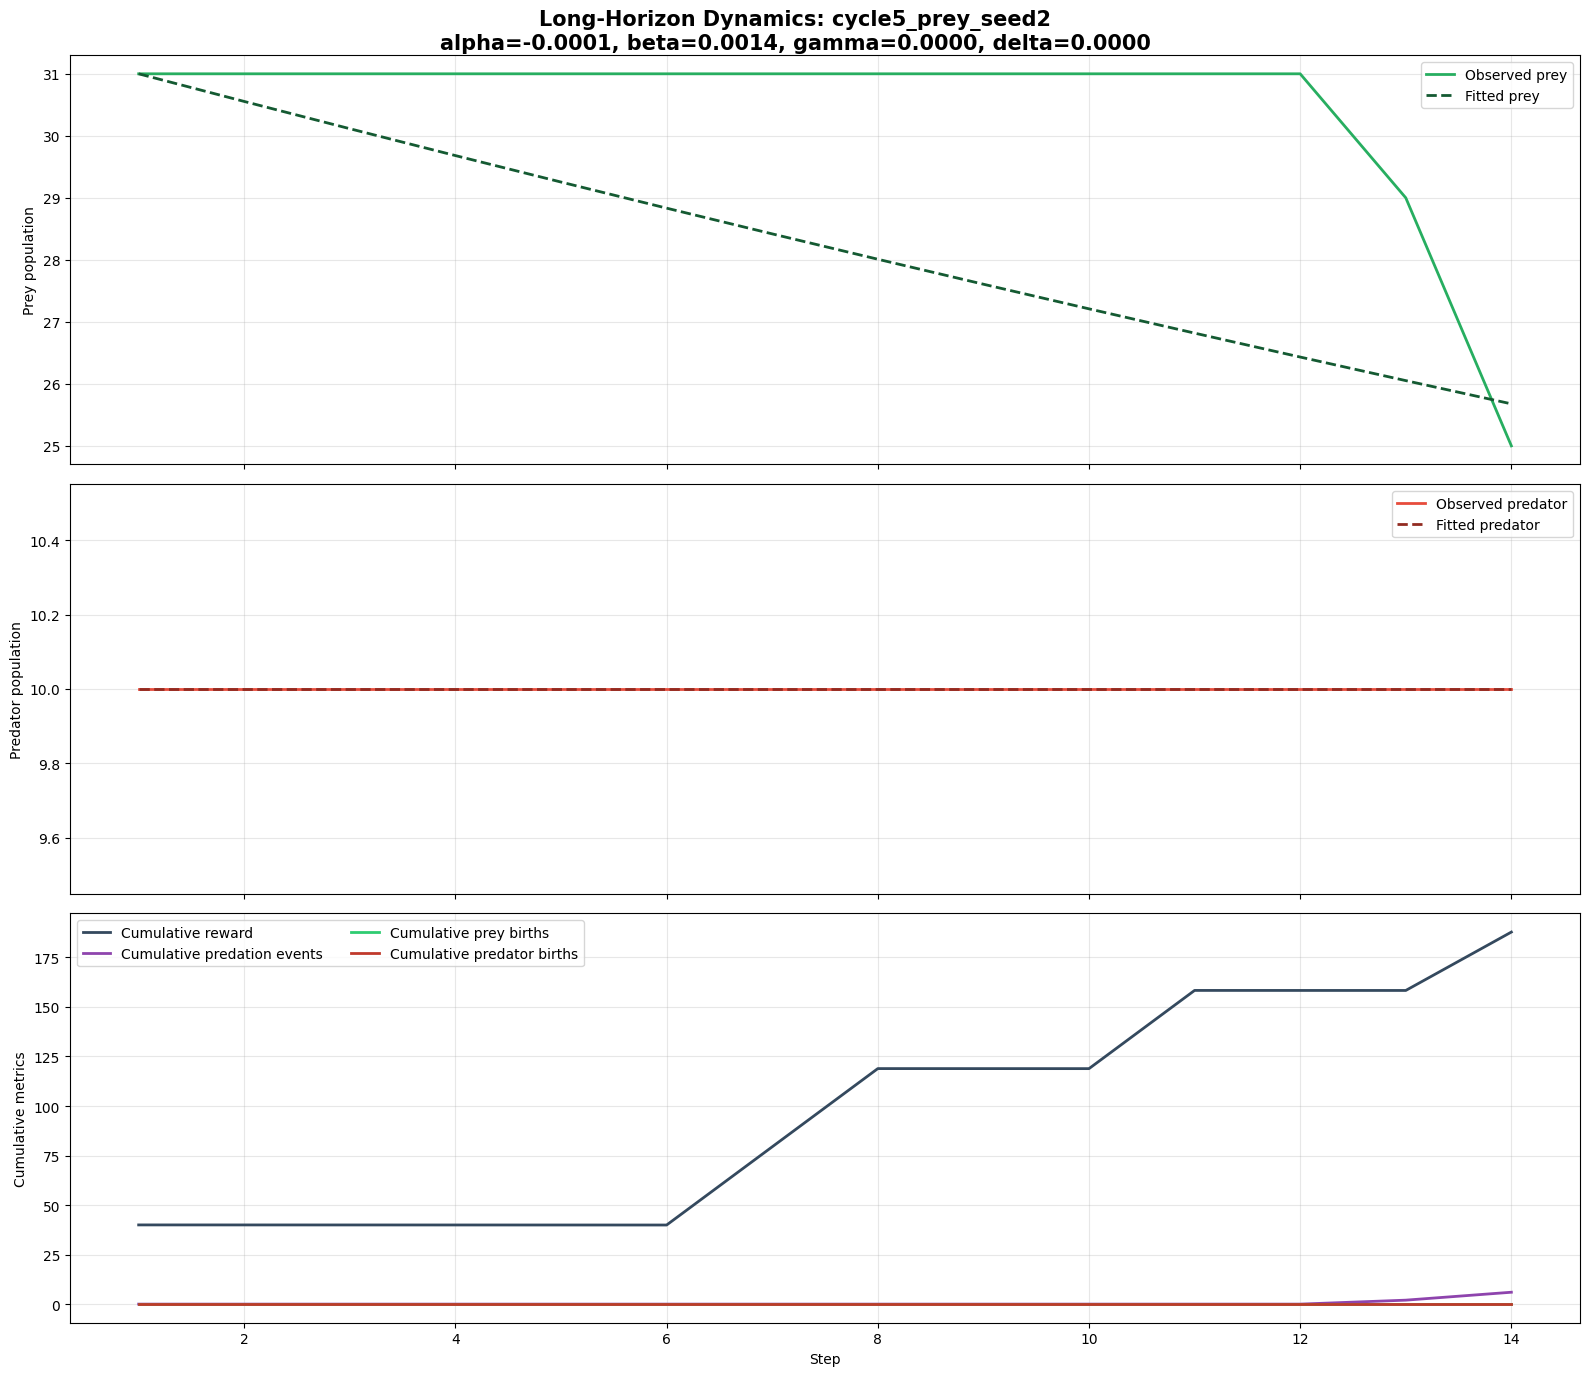

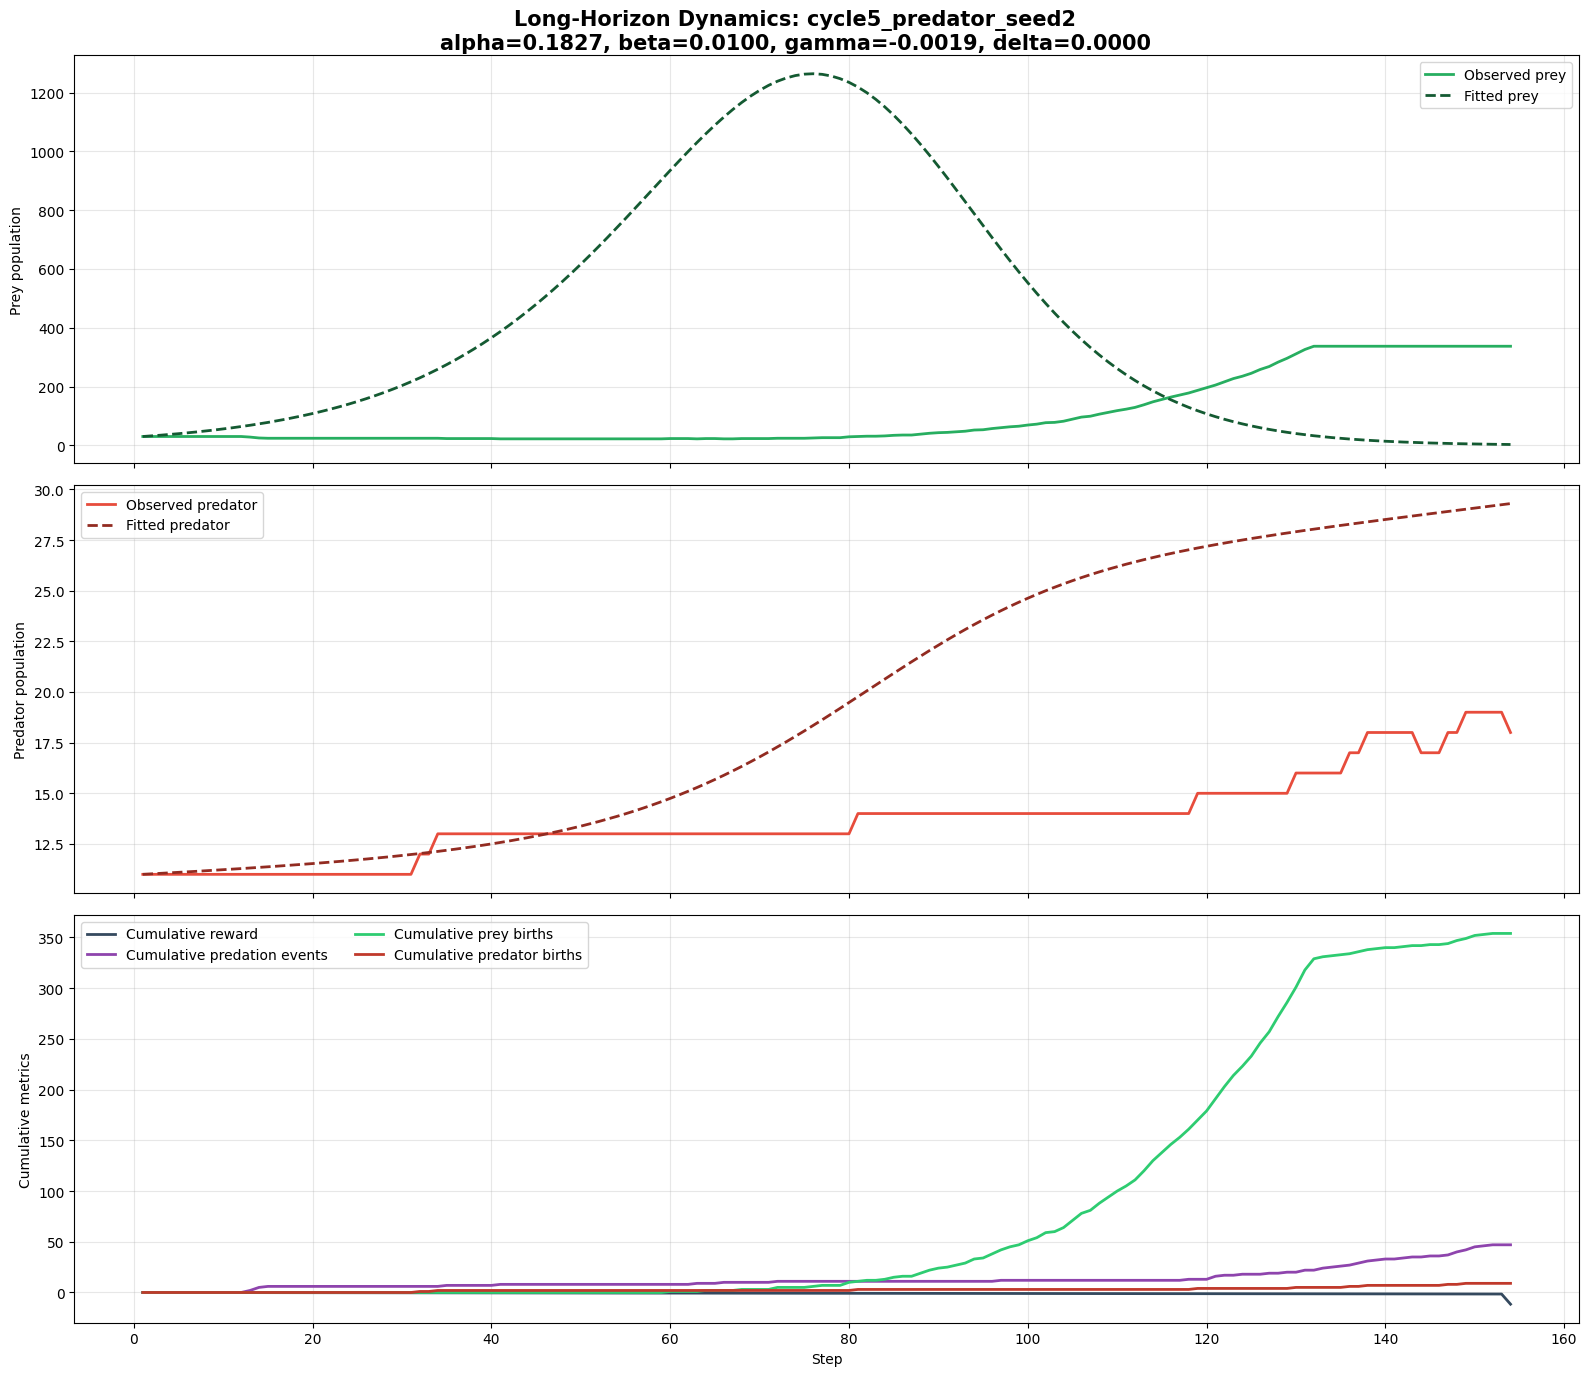

In [27]:
if not analysis_df.empty:
    analysis_csv_path = results_dir / 'long_horizon_fit_summary.csv'
    analysis_df.to_csv(analysis_csv_path, index=False)
    print(f'Saved fit summary to {analysis_csv_path}')

if all_run_frames:
    for run_df, analysis_row in zip(all_run_frames, analysis_rows):
        if not analysis_row.get('success', True):
            continue

        fit = fit_lotka_volterra(run_df)
        if not fit.get('success'):
            continue

        fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
        fig.suptitle(f"Long-Horizon Dynamics: {analysis_row.get('run_name', 'run')}\n"
                     f"alpha={fit['alpha']:.4f}, beta={fit['beta']:.4f}, gamma={fit['gamma']:.4f}, delta={fit['delta']:.4f}",
                     fontsize=15, fontweight='bold')

        step_axis = run_df['step'].to_numpy()
        axes[0].plot(step_axis, run_df['prey_population'], label='Observed prey', color='#27ae60', linewidth=2)
        axes[0].plot(step_axis, fit['prey_fitted'], label='Fitted prey', color='#145a32', linestyle='--', linewidth=2)
        axes[0].set_ylabel('Prey population')
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        axes[1].plot(step_axis, run_df['predator_population'], label='Observed predator', color='#e74c3c', linewidth=2)
        axes[1].plot(step_axis, fit['predator_fitted'], label='Fitted predator', color='#922b21', linestyle='--', linewidth=2)
        axes[1].set_ylabel('Predator population')
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        axes[2].plot(step_axis, run_df['cumulative_reward'], label='Cumulative reward', color='#34495e', linewidth=2)
        axes[2].plot(step_axis, run_df['cumulative_predation_events'], label='Cumulative predation events', color='#8e44ad', linewidth=2)
        axes[2].plot(step_axis, run_df['cumulative_prey_births'], label='Cumulative prey births', color='#2ecc71', linewidth=2)
        axes[2].plot(step_axis, run_df['cumulative_predator_births'], label='Cumulative predator births', color='#c0392b', linewidth=2)
        axes[2].set_xlabel('Step')
        axes[2].set_ylabel('Cumulative metrics')
        axes[2].legend(ncol=2)
        axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()
else:
    print('No run frames available for plotting.')